# NISAR DEM (v1.2): Access and Visualize

**Date:** March 4, 2026

**Author:** Harshini Girish (UAH), Alex Mandel (Development Seed), Chuck Daniels (Development Seed), Samantha Niemoeller (JPL)

**Description:** This notebook subsets a small Area of Interest (AOI) from the NISAR DEM VRT stored in ASF’s S3 bucket using rasterio’s `AWSSession` together with `rasterio.Env` for authenticated requester-pays S3 access. It logs in via Earthdata, requests temporary S3 credentials, opens the DEM directly from S3, clips the AOI in memory with `rioxarray`, and plots the result for quick inspection. This example intentionally focuses on access and in-memory subsetting; for a related MAAP example that writes an Xarray object to a cloud-optimized GeoTIFF (COG), see the Additional Resources section below.


## Run This Notebook

To access and run this tutorial within MAAP's Algorithm Development Environment (ADE), please refer to the ["Getting started with the MAAP"](https://docs.maap-project.org/en/latest/getting_started/getting_started.html) section of our documentation.

Disclaimer: it is highly recommended to run a tutorial within MAAP's ADE, which already includes packages specific to MAAP, such as maap-py. Running the tutorial outside of the MAAP ADE may lead to errors. Additionally, it is recommended to use the `Pangeo` workspace within the ADE, since certain packages relevant to this tutorial are already installed.

## About the Data

This notebook uses the **NISAR DEM v1.2** collection hosted by the **NASA Alaska Satellite Facility (ASF) DAAC**. It is a **global digital elevation model (DEM)** prepared for NISAR processing workflows and is **not derived from NISAR measurements**; instead, it is **modified from the Copernicus DEM 30 m** source product. Key modifications include converting the vertical reference from the **EGM2008 geoid to the WGS84 ellipsoid**, filling gaps (e.g., over ocean / missing tiles) to provide **complete global coverage**, and publishing the data through a **hierarchical VRT (Virtual Raster) structure** for fast, unified access. The top-level VRT file (**`EPSG4326.vrt`**) points to a second tier of VRTs organized by latitude bands, which in turn reference the underlying tiles; this makes it easy to access the DEM as one “virtual mosaic” without manually managing tile lists. Note: because elevations are ellipsoid-referenced, this dataset should **not** be used for applications that specifically require **geoid-based elevations**.

## Additional Resources

- [NISAR Access](https://docs.maap-project.org/en/latest/science/NISAR/NISAR_access.html)
- [Searching NISAR + BIOMASS Overlapping Data](https://docs.maap-project.org/en/develop/technical_tutorials/search/searching_NISAR_BIOMASS_overlapping_data.html)
- [ESA CCI Biomass V5.01 — Saving Tile as COG](https://docs.maap-project.org/en/latest/science/ESA_CCI/ESA_CCI_V5_Token_Access.html#saving-tile-as-cog)

For a related MAAP science example that shows writing a cloud-optimized GeoTIFF (COG) from an Xarray-backed workflow, see **ESA CCI Biomass V5.01 — Saving Tile as COG** above.


## Imports

Load all required libraries (`earthaccess` for authentication, `rasterio` for S3 access/session handling, `rioxarray` for in-memory clipping, and `matplotlib` for previewing the subset).


In [ ]:
import time

import matplotlib.pyplot as plt
import rasterio
import rioxarray
from rasterio.session import AWSSession

import earthaccess


## Parameters

Define the DEM version/projection directory and the AOI bounding box to subset.

In [2]:
# --- DEM version + projection directory ---
DEM_VERSION = "v1.2"
EPSG_DIR = "EPSG4326"  # also available: "EPSG3413" (Arctic), "EPSG3031" (Antarctic)

# --- AOI bbox ---
# For EPSG4326: lon/lat bbox (min_lon, min_lat, max_lon, max_lat)
BBOX = (-116.7, 35.9, -116.6, 36.0)

## VRT paths

Construct the VRT path in ASF’s S3 bucket. The /vsis3/ path is what rasterio/GDAL will read directly from S3.

In [3]:
# --- ASF S3 VRT (DEM mosaic as a VRT) ---
ASF_S3_BUCKET = "sds-n-cumulus-prod-nisar-products"
S3_KEY = f"DEM/{DEM_VERSION}/{EPSG_DIR}/{EPSG_DIR}.vrt"

S3_VRT_S3URI = f"s3://{ASF_S3_BUCKET}/{S3_KEY}"
S3_VRT_VSI = f"/vsis3/{ASF_S3_BUCKET}/{S3_KEY}"

S3_VRT_S3URI

's3://sds-n-cumulus-prod-nisar-products/DEM/v1.2/EPSG4326/EPSG4326.vrt'

## Set up Access

Log in via Earthdata and request short-lived S3 credentials from ASF so the S3 VRT can be accessed.

In [4]:
#Fetch temporary S3 credentials via Earthdata login
ASF_S3CREDS_ENDPOINT = "https://nisar.asf.earthdatacloud.nasa.gov/s3credentials"

auth = earthaccess.login()

creds = None
for attempt in range(1, 6):
    try:
        creds = auth.get_s3_credentials(endpoint=ASF_S3CREDS_ENDPOINT)
        print(f"Got S3 creds on attempt {attempt}")
        break
    except Exception as e:
        print(f"Attempt {attempt} failed:", type(e).__name__, e)
        time.sleep(5)

if creds is None:
    raise RuntimeError("Could not obtain ASF S3 credentials after retries.")

Got S3 creds on attempt 1


## AWS session setup

Create a rasterio `AWSSession` from the temporary ASF S3 credentials and use it with `rasterio.Env` for requester-pays S3 access.


In [11]:
session = AWSSession(
    aws_access_key_id=creds["accessKeyId"],
    aws_secret_access_key=creds["secretAccessKey"],
    aws_session_token=creds["sessionToken"],
    region_name="us-west-2",
    requester_pays=True,
)


## Subsetting helper

Define a helper function that opens the DEM from S3 inside a rasterio environment and clips the AOI in memory with `rioxarray`.


In [16]:
def open_dem_subset(dataset_path: str, bbox, session: AWSSession):
    """Open a DEM from S3 and clip the requested bounding box in memory."""
    minx, miny, maxx, maxy = bbox

    with rasterio.Env(session=session):
        rds = rioxarray.open_rasterio(dataset_path, mask_and_scale=True)
        clipped = rds.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy).load()

    return clipped


## Run subset in memory

Open the S3 VRT with the AWS session and clip the AOI in memory.


In [17]:
try:
    clipped = open_dem_subset(S3_VRT_S3URI, BBOX, session)
    print("Subset loaded in memory")
    print("CRS:", clipped.rio.crs)
    print("Bounds:", clipped.rio.bounds())
except Exception as e:
    print("S3 subset failed:", type(e).__name__, e)
    raise



Subset loaded in memory
CRS: EPSG:4326
Bounds: (-116.70013888888889, 35.89986111111111, -116.59986111111111, 36.00013888888889)


## Preview

Plot the clipped DEM directly from the in-memory Xarray object.


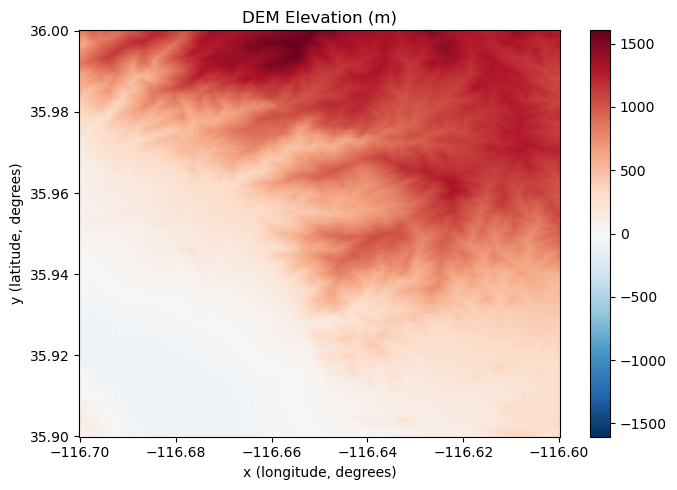

In [18]:
plt.figure(figsize=(7, 5))
clipped.squeeze().plot.imshow()
plt.title("DEM Elevation (m)")
plt.xlabel(f"{clipped.squeeze().dims[-1]} (longitude, degrees)")
plt.ylabel(f"{clipped.squeeze().dims[-2]} (latitude, degrees)")
plt.tight_layout()
plt.show()